In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [ ]:
class AgentState(TypedDict):
    name: str
    age: int
    final: str

In [8]:
def first_node(state: AgentState) -> AgentState:
    """This is the first node of our sequence"""
    name = state['name']
    
    state['final'] = f'Hi {name}! '
    return state

def second_node(state: AgentState) -> AgentState:
    """This is the first node of our sequence"""
    age = state['age']

    state['final'] += f'You are {age} years old'
    return state

In [9]:
graph = StateGraph(AgentState)

graph.add_node('name_node', first_node)
graph.add_node('age_node', second_node)

graph.set_entry_point('name_node')
graph.add_edge('name_node', 'age_node')
graph.set_finish_point('age_node')

app = graph.compile()

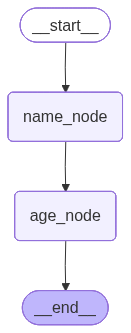

In [10]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [11]:
result = app.invoke({'name': 'Le', 'age': 30})
print(result)

{'name': 'Le', 'age': 30, 'final': 'Hi Le! You are 30 years old'}
